# Housing Price Drivers and Regression Analysis

## Project Overview

Housing prices are usually influenced by many factors at the same time, such as size, quality, number of rooms, age of the building, and location.

In this project, I analyze the Ames Housing dataset to understand which property characteristics are most strongly related to sale price. I start with exploratory analysis and then build regression models to check how well selected features can explain housing prices.

The main focus is not only to create a model, but also to understand what the model tells us and where its limitations are.

## Research Questions

The analysis is focused on a few practical questions:

- Which numerical features are most strongly related to house price?
- Is living area enough to explain price differences between properties?
- How important is overall quality compared with size?
- Can a regression model estimate house prices with reasonable accuracy?
- What are the main limitations of predicting price using only selected numerical variables?

##Import Libraries

In [39]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

##Display Settings

In [40]:
pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Initial Data Inspection

I start by checking the first rows, dataset size, column types, and basic descriptive statistics. This gives an initial understanding of the data and helps identify potential issues such as missing values, technical columns, or variables that may require cleaning before analysis.

In [41]:
df = pd.read_csv("/content/ames.csv")

## Initial Data Inspection

The first step is to inspect the structure of the dataset, including the number of observations, available variables, data types, and first rows.

In [42]:
df.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,Lot.Shape,Land.Contour,Utilities,Lot.Config,Land.Slope,Neighborhood,Condition.1,Condition.2,Bldg.Type,House.Style,Overall.Qual,Overall.Cond,Year.Built,Year.Remod.Add,Roof.Style,Roof.Matl,Exterior.1st,Exterior.2nd,Mas.Vnr.Type,Mas.Vnr.Area,Exter.Qual,Exter.Cond,Foundation,Bsmt.Qual,Bsmt.Cond,Bsmt.Exposure,BsmtFin.Type.1,BsmtFin.SF.1,BsmtFin.Type.2,BsmtFin.SF.2,Bsmt.Unf.SF,Total.Bsmt.SF,Heating,Heating.QC,Central.Air,Electrical,X1st.Flr.SF,X2nd.Flr.SF,Low.Qual.Fin.SF,Bsmt.Full.Bath,Bsmt.Half.Bath,Full.Bath,Half.Bath,Bedroom.AbvGr,Kitchen.AbvGr,Kitchen.Qual,TotRms.AbvGrd,Functional,Fireplaces,Fireplace.Qu,Garage.Type,Garage.Yr.Blt,Garage.Finish,Garage.Cars,Garage.Area,Garage.Qual,Garage.Cond,Paved.Drive,Wood.Deck.SF,Open.Porch.SF,Enclosed.Porch,X3Ssn.Porch,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.000,Unf,0.000,441.000,"1,080.000",GasA,Fa,Y,SBrkr,1656,0,0,1.000,0.000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.000",Fin,2.000,528.000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.000,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.000,Gd,TA,CBlock,TA,TA,No,ALQ,"1,065.000",Unf,0.000,"1,045.000","2,110.000",GasA,Ex,Y,SBrkr,2110,0,0,1.000,0.000,2,1,3,1,Ex,8,Typ,2,TA,Attchd,"1,968.000",Fin,2.000,522.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [43]:
print("Dataset shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset shape:
Rows: 2930
Columns: 82


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   area             2930 non-null   int64  
 3   price            2930 non-null   int64  
 4   MS.SubClass      2930 non-null   int64  
 5   MS.Zoning        2930 non-null   object 
 6   Lot.Frontage     2440 non-null   float64
 7   Lot.Area         2930 non-null   int64  
 8   Street           2930 non-null   object 
 9   Alley            198 non-null    object 
 10  Lot.Shape        2930 non-null   object 
 11  Land.Contour     2930 non-null   object 
 12  Utilities        2930 non-null   object 
 13  Lot.Config       2930 non-null   object 
 14  Land.Slope       2930 non-null   object 
 15  Neighborhood     2930 non-null   object 
 16  Condition.1      2930 non-null   object 
 17  Condition.2   

In [45]:
df.describe()

,Order,PID,area,price,MS.SubClass,Lot.Frontage,Lot.Area,Overall.Qual,Overall.Cond,Year.Built,Year.Remod.Add,Mas.Vnr.Area,BsmtFin.SF.1,BsmtFin.SF.2,Bsmt.Unf.SF,Total.Bsmt.SF,X1st.Flr.SF,X2nd.Flr.SF,Low.Qual.Fin.SF,Bsmt.Full.Bath,Bsmt.Half.Bath,Full.Bath,Half.Bath,Bedroom.AbvGr,Kitchen.AbvGr,TotRms.AbvGrd,Fireplaces,Garage.Yr.Blt,Garage.Cars,Garage.Area,Wood.Deck.SF,Open.Porch.SF,Enclosed.Porch,X3Ssn.Porch,Screen.Porch,Pool.Area,Misc.Val,Mo.Sold,Yr.Sold
count,"2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,440.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,907.000","2,929.000","2,929.000","2,929.000","2,929.000","2,930.000","2,930.000","2,930.000","2,928.000","2,928.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,771.000","2,929.000","2,929.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000"
mean,"1,465.500","714,464,496.989","1,499.690","180,796.060",57.387,69.225,"10,147.922",6.095,5.563,"1,971.356","1,984.267",101.897,442.630,49.722,559.263,"1,051.615","1,159.558",335.456,4.677,0.431,0.061,1.567,0.380,2.854,1.044,6.443,0.599,"1,978.132",1.767,472.820,93.752,47.533,23.012,2.592,16.002,2.243,50.635,6.216,"2,007.790"
std,845.962,"188,730,844.649",505.509,"79,886.692",42.638,23.365,"7,880.018",1.411,1.112,30.245,20.860,179.113,455.591,169.168,439.494,440.615,391.891,428.396,46.311,0.525,0.245,0.553,0.503,0.828,0.214,1.573,0.648,25.528,0.761,215.047,126.362,67.483,64.139,25.141,56.087,35.597,566.344,2.714,1.317
min,1.000,"526,301,100.000",334.000,"12,789.000",20.000,21.000,"1,300.000",1.000,1.000,"1,872.000","1,950.000",0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,"1,895.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"2,006.000"
25%,733.250,"528,477,022.500","1,126.000","129,500.000",20.000,58.000,"7,440.250",5.000,5.000,"1,954.000","1,965.000",0.000,0.000,0.000,219.000,793.000,876.250,0.000,0.000,0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,"1,960.000",1.000,320.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000,"2,007.000"
50%,"1,465.500","535,453,620.000","1,442.000","160,000.000",50.000,68.000,"9,436.500",6.000,5.000,"1,973.000","1,993.000",0.000,370.000,0.000,466.000,990.000,"1,084.000",0.000,0.000,0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,"1,979.000",2.000,480.000,0.000,27.000,0.000,0.000,0.000,0.000,0.000,6.000,"2,008.000"
75%,"2,197.750","907,181,097.500","1,742.750","213,500.000",70.000,80.000,"11,555.250",7.000,6.000,"2,001.000","2,004.000",164.000,734.000,0.000,802.000,"1,302.000","1,384.000",703.750,0.000,1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,"2,002.000",2.000,576.000,168.000,70.000,0.000,0.000,0.000,0.000,0.000,8.000,"2,009.000"
max,"2,930.000","1,007,100,110.000","5,642.000","755,000.000",190.000,313.000,"215,245.000",10.000,9.000,"2,010.000","2,010.000","1,600.000","5,644.000","1,526.000","2,336.000","6,110.000","5,095.000","2,065.000","1,064.000",3.000,2.000,4.000,2.000,8.000,3.000,15.000,4.000,"2,207.000",5.000,"1,488.000","1,424.000",742.000,"1,012.000",508.000,576.000,800.000,"17,000.000",12.000,"2,010.000"


## Dataset Overview

The dataset contains **2,930 residential property records** and **82 variables** describing different aspects of each property.

The data includes information about property size, rooms, construction year, quality ratings, neighborhood, and final sale price. Since the dataset contains many variables, this project focuses on a smaller group of numerical features that are easier to interpret and suitable for regression modeling.

The target variable is:

- `price` – final sale price of the property.

The selected explanatory variables are:

- `area` – above-ground living area,
- `Bedroom.AbvGr` – number of bedrooms above ground,
- `TotRms.AbvGrd` – total number of rooms above ground,
- `Year.Built` – original construction year,
- `Overall.Qual` – overall material and finish quality.

These features were selected because they represent basic property characteristics that are likely to influence housing price.

## Selecting and Renaming Key Variables

The original dataset contains many columns, including categorical features and detailed property attributes. For this part of the analysis, I focus on selected numerical variables that can be used directly in regression models.

I also rename the selected columns to make the code easier to read and the analysis easier to follow.

In [46]:
selected_columns = {
    "price": "price",
    "area": "area",
    "Bedroom.AbvGr": "bedrooms",
    "TotRms.AbvGrd": "total_rooms",
    "Year.Built": "year_built",
    "Overall.Qual": "overall_quality"
}

housing = df[list(selected_columns.keys())].rename(columns=selected_columns).copy()

housing.head()

,price,area,bedrooms,total_rooms,year_built,overall_quality
0,215000,1656,3,7,1960,6
1,105000,896,2,5,1961,5
2,172000,1329,3,6,1958,6
3,244000,2110,3,8,1968,7
4,189900,1629,3,6,1997,5


## Data Quality Check

Before analyzing relationships between variables, I check whether the selected columns contain missing values or duplicated rows.

This step is important because missing values can affect statistical results and model training. Duplicates are also reviewed, but they should not be removed automatically, since similar property records may still represent different houses.

In [47]:
missing_values = housing.isna().sum()

missing_values

,0
price,0
area,0
bedrooms,0
total_rooms,0
year_built,0
overall_quality,0


In [48]:
duplicate_rows = housing.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 11


### Interpretation

The selected variables do not contain missing values, so no imputation or row removal is required before the analysis.

The simplified working dataset contains 11 repeated rows based only on the selected variables. I do not remove them automatically, because these repeated combinations may still represent different properties in the original dataset. In housing data, it is possible for multiple houses to have the same price, size, number of rooms, year built, and quality rating.

## Summary Statistics

I use descriptive statistics to understand the scale and distribution of the selected variables.

This helps identify typical property values, the range of prices and living area, and possible extreme observations that may affect the regression model later.

In [49]:
housing.describe()

,price,area,bedrooms,total_rooms,year_built,overall_quality
count,"2,930.000","2,930.000","2,930.000","2,930.000","2,930.000","2,930.000"
mean,"180,796.060","1,499.690",2.854,6.443,"1,971.356",6.095
std,"79,886.692",505.509,0.828,1.573,30.245,1.411
min,"12,789.000",334.000,0.000,2.000,"1,872.000",1.000
25%,"129,500.000","1,126.000",2.000,5.000,"1,954.000",5.000
50%,"160,000.000","1,442.000",3.000,6.000,"1,973.000",6.000
75%,"213,500.000","1,742.750",3.000,7.000,"2,001.000",7.000
max,"755,000.000","5,642.000",8.000,15.000,"2,010.000",10.000


### Interpretation

The average sale price is around **180,797**, while the median price is **160,000**. Since the mean is higher than the median, the price distribution is likely right-skewed, meaning that more expensive properties pull the average upward.

The typical property in this selected dataset has about **1,500 square feet** of living area, **3 bedrooms**, and **6 total rooms**. Most houses were built between **1954 and 2001**, based on the interquartile range.

The `overall_quality` variable ranges from **1 to 10**, with a median value of **6**, suggesting that most properties are rated around average to above average quality. The wide range of prices and living area also suggests that some extreme observations may be present and should be checked during exploratory analysis.

# Exploratory Data Analysis

I start the exploratory analysis by looking at the target variable and the main numerical features. This helps understand how the data is distributed before building regression models.

The main focus is on price, living area, overall quality, and their relationship with each other.

## Price Distribution

Before analyzing price drivers, I first check how sale prices are distributed across the dataset.

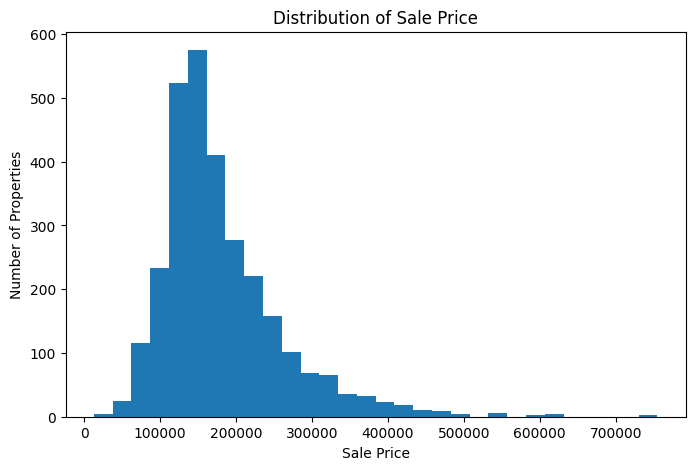

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(
    housing["price"],
    bins=30
)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Number of Properties")

plt.show()

### Interpretation

The sale price distribution is clearly right-skewed. Most properties are concentrated in the lower and middle price ranges, mainly between approximately **100,000 and 250,000**.

There are fewer high-priced properties, but they extend the distribution far to the right, with some houses priced above **500,000**. This explains why the average price is higher than the median price observed in the summary statistics.

This pattern is common in housing data: most homes are sold at moderate prices, while a smaller number of expensive properties increases the upper tail of the distribution.

## Living Area Distribution

After checking sale prices, I look at the distribution of living area. This helps understand the typical size of properties in the dataset and whether there are unusually large houses that may affect the regression model.

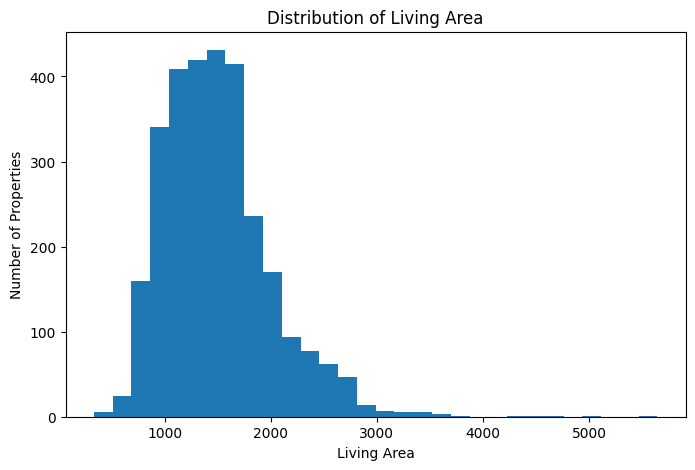

In [51]:
plt.figure(figsize=(8, 5))

plt.hist(
    housing["area"],
    bins=30
)

plt.title("Distribution of Living Area")
plt.xlabel("Living Area")
plt.ylabel("Number of Properties")

plt.show()

### Interpretation

The living area distribution is right-skewed. Most properties have a living area between approximately **1,000 and 2,000 square feet**, which matches the median value of **1,442** observed in the summary statistics.

There are also a few much larger properties, with living area above **3,000 square feet** and some extreme values above **5,000 square feet**. These observations may have a noticeable impact on the regression model, especially if they are also associated with very high or unusually low sale prices.

This suggests that living area is likely an important feature to analyze, but possible outliers should be kept in mind when interpreting the model.

## Overall Quality Distribution

Next, I check how overall quality ratings are distributed in the dataset. This variable is important because property quality may explain price differences that are not visible from living area alone.

In [52]:
quality_counts = housing["overall_quality"].value_counts().sort_index()

quality_counts

,count
overall_quality,
1,4
2,13
3,40
4,226
5,825
6,732
7,602
8,350
9,107


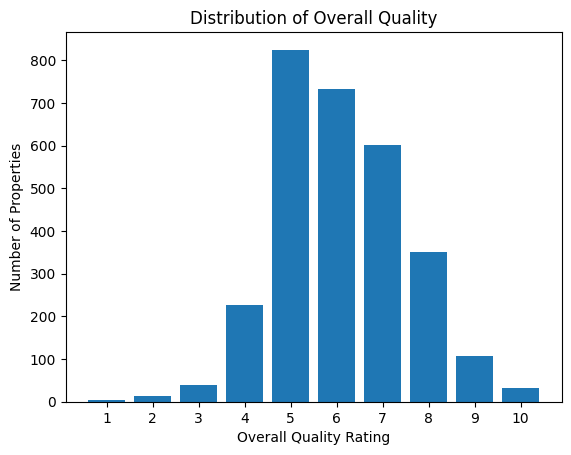

In [53]:
plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.title("Distribution of Overall Quality")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Number of Properties")
plt.xticks(quality_counts.index)

plt.show()

### Interpretation

Most properties are rated between **5 and 7** in overall quality, with rating **5** being the most common. This means that the dataset is mainly composed of average to above-average quality homes.

Very low quality ratings, such as **1–3**, are rare. Very high quality ratings, especially **9–10**, are also much less common. This suggests that luxury or top-quality properties represent only a small part of the dataset.

Since overall quality captures the general material and finish standard of a property, it may be an important factor in explaining differences in sale price. This will be checked later using correlation analysis and regression modeling.

## Price vs Living Area

After checking the distributions, I compare sale price with living area. This helps verify whether larger properties generally sell for higher prices and whether the relationship looks suitable for regression modeling.

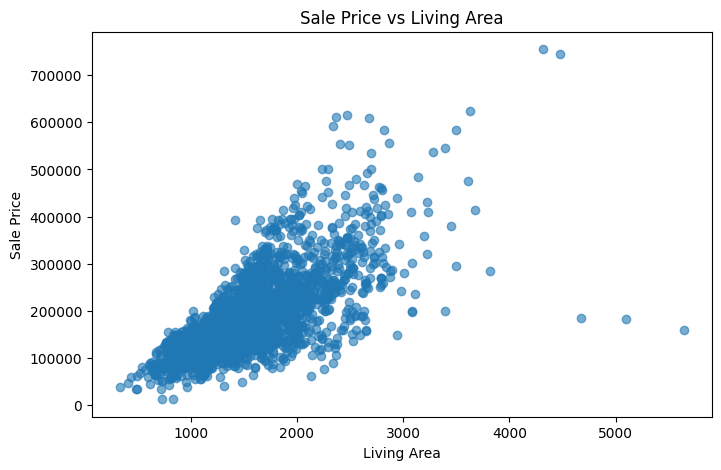

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(
    housing["area"],
    housing["price"],
    alpha=0.6
)

plt.title("Sale Price vs Living Area")
plt.xlabel("Living Area")
plt.ylabel("Sale Price")

plt.show()

### Interpretation

The scatter plot shows a clear positive relationship between living area and sale price. In general, larger properties tend to sell for higher prices.

However, the relationship is not perfectly linear. Houses with a similar living area can still have very different prices, which means that size alone does not fully explain property value. Other factors, such as overall quality, location, age, and condition, are likely to play an important role.

There are also a few unusual observations with very large living area but relatively low sale price. These points may influence the regression line and should be kept in mind when interpreting the simple linear regression model.

## Sale Price by Overall Quality

Living area shows a positive relationship with price, but size alone does not explain all price differences. I now compare sale prices across overall quality ratings to see whether better-rated properties are consistently more expensive.

In [55]:
quality_price_summary = (
    housing
    .groupby("overall_quality")["price"]
    .agg(["count", "mean", "median", "min", "max"])
)

quality_price_summary

,count,mean,median,min,max
overall_quality,,,,,
1,4,"48,725.000","50,150.000",13100,81500
2,13,"52,325.308","57,625.000",12789,82000
3,40,"83,185.975","81,200.000",37900,139600
4,226,"106,485.097","105,000.000",34900,256000
5,825,"134,752.516","133,000.000",55993,301600
6,732,"162,130.318","159,500.000",76000,415000
7,602,"205,025.761","200,000.000",82500,383970
8,350,"270,913.594","264,530.500",122000,538000
9,107,"368,336.766","360,000.000",150000,611657


<Figure size 900x500 with 0 Axes>

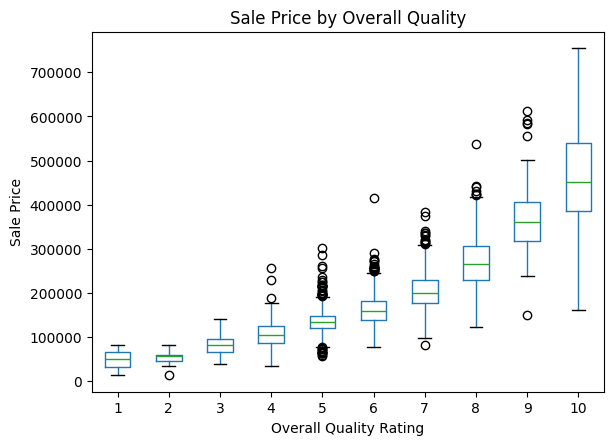

In [56]:
plt.figure(figsize=(9, 5))

housing.boxplot(
    column="price",
    by="overall_quality",
    grid=False
)

plt.title("Sale Price by Overall Quality")
plt.suptitle("")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price")

plt.show()

### Interpretation

Sale price increases clearly with overall quality. Properties rated **8, 9, and 10** have much higher median prices than properties with average or low quality ratings.

The difference between quality groups is stronger and more consistent than what was visible for living area alone. This suggests that overall quality may be one of the most important variables for explaining house prices in this dataset.

There are still outliers within several quality groups, especially for ratings **5–9**, which means that quality is important but does not explain the full price variation by itself. Other factors, such as living area, location, age, and property condition, may also influence the final sale price.

# Correlation Analysis

After looking at the charts, I calculate correlations to measure how strongly each selected numerical feature is related to sale price.

This step helps identify which variables are most useful for regression modeling and whether the visual patterns observed earlier are also confirmed numerically.

In [57]:
correlation_matrix = housing.corr()

correlation_matrix

,price,area,bedrooms,total_rooms,year_built,overall_quality
price,1.000,0.707,0.144,0.495,0.558,0.799
area,0.707,1.000,0.517,0.808,0.242,0.571
bedrooms,0.144,0.517,1.000,0.673,-0.055,0.063
total_rooms,0.495,0.808,0.673,1.000,0.112,0.381
year_built,0.558,0.242,-0.055,0.112,1.000,0.597
overall_quality,0.799,0.571,0.063,0.381,0.597,1.000


In [58]:
price_correlations = (
    correlation_matrix["price"]
    .sort_values(ascending=False)
)

price_correlations

,price
price,1.000
overall_quality,0.799
area,0.707
year_built,0.558
total_rooms,0.495
bedrooms,0.144


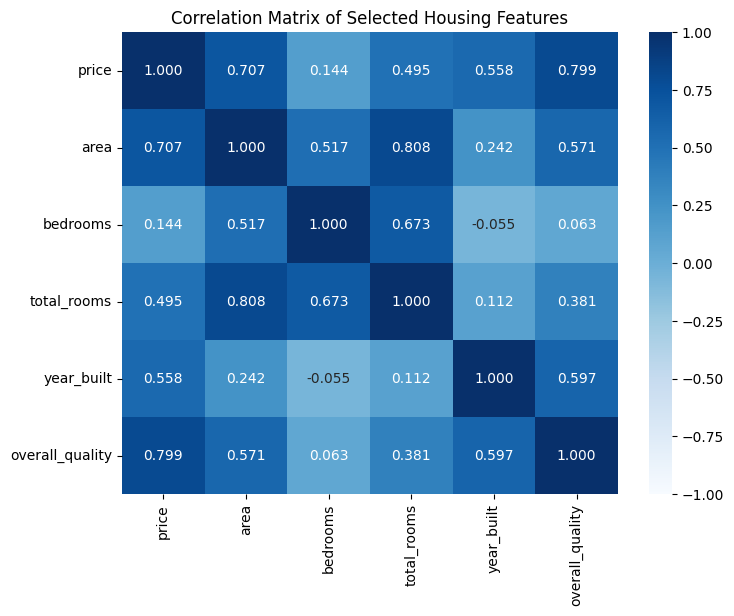

In [59]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Selected Housing Features")

plt.show()

### Interpretation

The strongest correlation with sale price is observed for **overall quality** (`r = 0.799`). This suggests that the general quality of materials and finish is the most important price-related feature among the selected variables.

Living area also has a strong positive relationship with price (`r = 0.707`). This confirms what was visible in the scatter plot: larger houses usually sell for higher prices, although size alone does not explain all price differences.

`Year built` has a moderate positive correlation with price (`r = 0.558`), which may indicate that newer houses tend to be more expensive. `Total rooms` also shows a moderate relationship with price (`r = 0.495`), while the number of bedrooms has only a weak correlation (`r = 0.144`).

It is also worth noting that some predictors are correlated with each other. For example, living area and total rooms have a strong correlation (`r = 0.808`). This makes sense because larger houses usually have more rooms, but it also means that these variables may partly explain the same information in a regression model.

# Simple Linear Regression

I first build a simple linear regression model using only living area as the predictor of sale price.

This is a good starting point because living area has a strong positive correlation with price and is easy to interpret. However, based on the previous charts, I already expect that area alone will not explain all differences in property prices.

## Preparing Variables

The model uses living area as the explanatory variable and sale price as the target variable.

In [60]:
X_simple = housing[["area"]]
y = housing["price"]

## Train-Test Split

I split the data into training and testing sets. The model is trained on one part of the data and evaluated on unseen observations.

This helps check whether the model can generalize, instead of only fitting the data it has already seen.

In [61]:
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train_simple))
print("Testing observations:", len(X_test_simple))

Training observations: 2344
Testing observations: 586


## Model Training

The simple linear regression model is trained using the training data.

In [62]:
simple_model = LinearRegression()

simple_model.fit(X_train_simple, y_train)

LinearRegression()

## Regression Coefficient

The regression coefficient shows how much the predicted sale price changes when living area increases by one square foot.

In [63]:
simple_coefficient = simple_model.coef_[0]
simple_intercept = simple_model.intercept_

print("Coefficient:", round(simple_coefficient, 2))
print("Intercept:", round(simple_intercept, 2))

Coefficient: 106.73
Intercept: 19250.56


### Interpretation

The coefficient is approximately **106.73**, which means that the model estimates an increase of about **106.73 in sale price** for each additional square foot of living area.

The relationship is positive, which is consistent with the scatter plot and correlation analysis: larger properties generally tend to sell for higher prices.

The intercept is about **19,250.56**, but it should not be interpreted too literally, because a property with zero living area is not realistic. In this model, the intercept mainly helps define the position of the regression line.

## Regression Line

The regression line shows the average price trend estimated by the model based only on living area.

In [64]:
area_range = np.linspace(
    housing["area"].min(),
    housing["area"].max(),
    100
)

predicted_price_line = simple_model.predict(
    pd.DataFrame({"area": area_range})
)

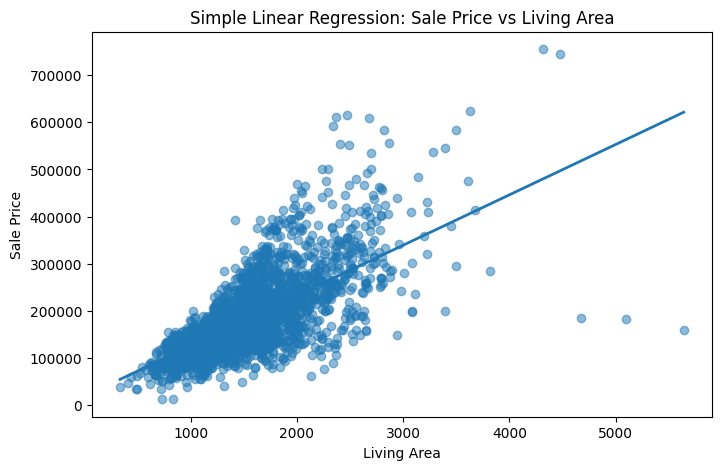

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(
    housing["area"],
    housing["price"],
    alpha=0.5
)

plt.plot(
    area_range,
    predicted_price_line,
    linewidth=2
)

plt.title("Simple Linear Regression: Sale Price vs Living Area")
plt.xlabel("Living Area")
plt.ylabel("Sale Price")

plt.show()

### Interpretation

The regression line confirms a positive relationship between living area and sale price. As living area increases, the predicted sale price also increases.

However, the points are not evenly concentrated around the line. For larger properties, price differences become more visible, and a few large houses have relatively low sale prices compared with what the model would expect.

This means that living area is an important predictor, but it does not fully explain house prices on its own. Other features, especially overall quality, are likely needed to improve the model.

## Model Evaluation

I evaluate the model on the test set using standard regression metrics.

In [66]:
y_pred_simple = simple_model.predict(X_test_simple)

simple_r2 = r2_score(y_test, y_pred_simple)
simple_mae = mean_absolute_error(y_test, y_pred_simple)
simple_mse = mean_squared_error(y_test, y_pred_simple)
simple_rmse = np.sqrt(simple_mse)

simple_model_metrics = pd.DataFrame({
    "Metric": ["R²", "MAE", "MSE", "RMSE"],
    "Value": [
        round(simple_r2, 4),
        round(simple_mae, 2),
        round(simple_mse, 2),
        round(simple_rmse, 2)
    ]
})

simple_model_metrics

,Metric,Value
0,R²,0.523
1,MAE,"41,365.510"
2,MSE,"3,821,184,066.270"
3,RMSE,"61,815.730"


### Interpretation

The simple linear regression model explains about **52.3%** of the variation in sale price, based on the R² value. This is a reasonable result for a model using only one predictor.

The mean absolute error is approximately **41,366**, which means that, on average, the model's predictions differ from the actual sale prices by about 41 thousand price units.

The RMSE is higher, at around **61,816**, which suggests that larger prediction errors occur for some properties. This is expected because the scatter plot showed several unusual observations, especially among larger houses.

Overall, living area is a useful predictor of sale price, but the model still leaves a large part of price variation unexplained. A multiple regression model with additional features should provide a better understanding of housing prices.

## Living Area vs Overall Quality

Before building the multiple regression model, I also check the relationship between living area and overall quality. This helps understand whether larger houses also tend to have higher quality ratings.

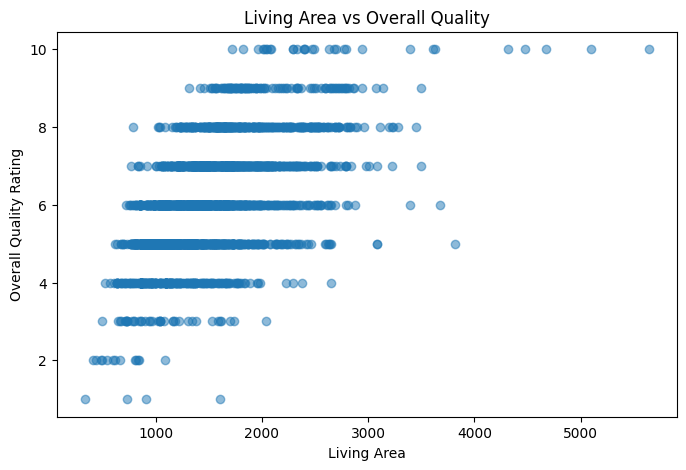

In [75]:
plt.figure(figsize=(8, 5))

plt.scatter(
    housing["area"],
    housing["overall_quality"],
    alpha=0.5
)

plt.title("Living Area vs Overall Quality")
plt.xlabel("Living Area")
plt.ylabel("Overall Quality Rating")

plt.show()

### Interpretation

The chart suggests that larger properties often have higher overall quality ratings, but the relationship is not perfectly linear.

Most properties are concentrated between quality ratings **5 and 7**, even when living area differs. This means that size and quality are related to some extent, but they still capture different aspects of a property.

This is important for regression modeling because both variables may help explain sale price. Living area describes the size of the house, while overall quality reflects the standard of materials and finish.

# Multiple Linear Regression

The simple linear regression model showed that living area is a useful predictor of sale price, but it does not explain all price differences.

In the next step, I build a multiple linear regression model using several property features. This allows the model to consider not only size, but also quality, age, and room-related characteristics.

## Preparing Features

The multiple regression model uses selected numerical features that were previously explored in the analysis.

In [67]:
multiple_features = [
    "area",
    "bedrooms",
    "total_rooms",
    "year_built",
    "overall_quality"
]

X_multiple = housing[multiple_features]
y = housing["price"]

## Train-Test Split

The same train-test split strategy is used to make the multiple regression model comparable with the simple regression model.

In [68]:
X_train_multiple, X_test_multiple, y_train, y_test = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train_multiple))
print("Testing observations:", len(X_test_multiple))

Training observations: 2344
Testing observations: 586


## Model Training

The multiple linear regression model is trained using living area, number of bedrooms, total rooms, year built, and overall quality as predictors.

In [69]:
multiple_model = LinearRegression()

multiple_model.fit(X_train_multiple, y_train)

LinearRegression()

## Model Coefficients

The coefficients show how each feature is associated with sale price when the other variables in the model are held constant.

In [70]:
multiple_coefficients = pd.DataFrame({
    "Feature": multiple_features,
    "Coefficient": multiple_model.coef_
}).sort_values("Coefficient", ascending=False)

multiple_coefficients

,Feature,Coefficient
4,overall_quality,"23,305.242"
3,year_built,491.335
0,area,75.877
2,total_rooms,-741.805
1,bedrooms,"-10,792.259"


### Interpretation

The coefficients show how each variable is associated with sale price while the other variables are kept in the model.

`overall_quality` has the largest positive coefficient. According to the model, increasing the quality rating by one point is associated with an increase of about **23,305** in predicted sale price, assuming the other variables stay the same.

Living area also has a positive coefficient. After accounting for quality, year built, rooms, and bedrooms, each additional square foot is associated with an increase of about **75.88** in predicted sale price.

The coefficient for `year_built` is also positive, suggesting that newer houses tend to have higher predicted prices when the other selected features are controlled for.

The negative coefficients for `bedrooms` and `total_rooms` should be interpreted carefully. They do not mean that rooms directly reduce property value. These variables are related to living area and to each other, so their coefficients can change when they are included in the same model. This is a good reminder that regression coefficients should be interpreted in context, not as simple standalone relationships.

## Model Evaluation

The multiple regression model is evaluated on the test set using the same metrics as the simple regression model.

In [71]:
y_pred_multiple = multiple_model.predict(X_test_multiple)

multiple_r2 = r2_score(y_test, y_pred_multiple)
multiple_mae = mean_absolute_error(y_test, y_pred_multiple)
multiple_mse = mean_squared_error(y_test, y_pred_multiple)
multiple_rmse = np.sqrt(multiple_mse)

multiple_model_metrics = pd.DataFrame({
    "Metric": ["R²", "MAE", "MSE", "RMSE"],
    "Value": [
        round(multiple_r2, 4),
        round(multiple_mae, 2),
        round(multiple_mse, 2),
        round(multiple_rmse, 2)
    ]
})

multiple_model_metrics

,Metric,Value
0,R²,0.767
1,MAE,"28,322.210"
2,MSE,"1,867,414,367.710"
3,RMSE,"43,213.590"


### Interpretation

The multiple linear regression model explains about **76.7%** of the variation in sale price, based on the R² value. This is a clear improvement compared with the simple model based only on living area.

The average prediction error is approximately **28,322**, which means that the model's predictions differ from actual sale prices by about 28 thousand price units on average.

The RMSE is approximately **43,214**, which is higher than MAE. This suggests that the model still makes larger errors for some properties, likely because housing prices are affected by additional factors not included in this simplified model, such as neighborhood, condition, basement features, garage quality, or lot characteristics.

Overall, the model performs reasonably well for a small set of numerical predictors, but it should not be treated as a complete pricing model.

## Model Comparison

I compare the simple model with the multiple regression model to check whether adding more property features improves prediction quality.

In [72]:
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "R²": [
        round(simple_r2, 4),
        round(multiple_r2, 4)
    ],
    "MAE": [
        round(simple_mae, 2),
        round(multiple_mae, 2)
    ],
    "RMSE": [
        round(simple_rmse, 2),
        round(multiple_rmse, 2)
    ]
})

model_comparison

,Model,R²,MAE,RMSE
0,Simple Linear Regression,0.523,"41,365.510","61,815.730"
1,Multiple Linear Regression,0.767,"28,322.210","43,213.590"


### Interpretation

Adding more property features improved the model substantially.

The simple linear regression model explained **52.3%** of sale price variation, while the multiple linear regression model explained **76.7%**. This means that property price is not driven by living area alone.

The prediction error also decreased. MAE dropped from about **41,366** to **28,322**, and RMSE decreased from about **61,816** to **43,214**.

This confirms that variables such as overall quality, year built, number of rooms, and bedrooms add useful information to the model. Among the selected features, overall quality appears to be especially important for explaining house prices.

## Actual vs Predicted Prices

To better understand the model performance, I compare actual sale prices with the prices predicted by the multiple regression model.

If the model performed perfectly, the points would be close to the diagonal reference line.

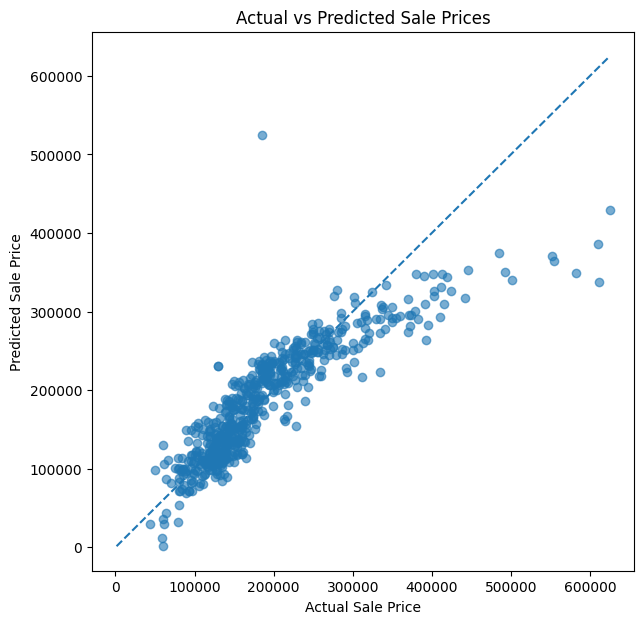

In [73]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_multiple,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_multiple.min())
max_value = max(y_test.max(), y_pred_multiple.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Sale Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.show()

### Interpretation

The actual vs predicted plot shows that the model performs reasonably well for lower and mid-range properties. Most observations are located close to the diagonal line, which means that predicted prices are often fairly close to actual sale prices.

However, the model is less accurate for more expensive properties. For houses with higher actual prices, many points fall below the diagonal line, which means that the model tends to underestimate expensive homes.

This suggests that the selected numerical features explain a large part of price variation, but they are still not enough to fully capture what makes some properties significantly more expensive.

## Residual Analysis

Residuals show the difference between actual and predicted prices.

I use a residual plot to check whether prediction errors are randomly distributed or whether the model shows visible patterns of error.

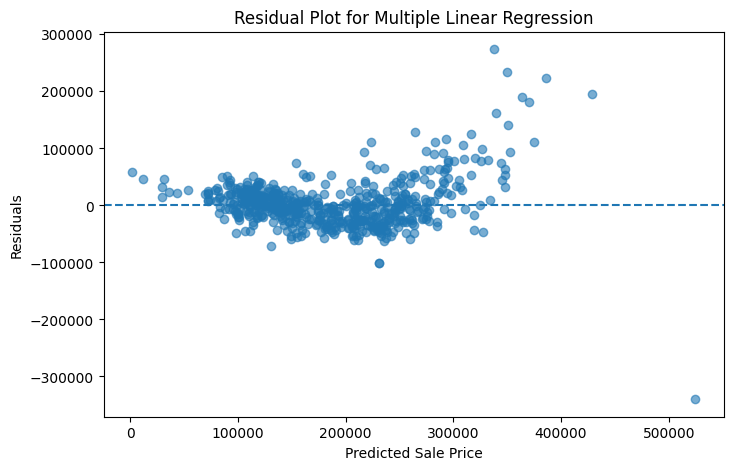

In [74]:
residuals_multiple = y_test - y_pred_multiple

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_multiple,
    residuals_multiple,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot for Multiple Linear Regression")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.show()

### Interpretation

The residual plot shows that prediction errors are not perfectly random. For lower and mid-range predicted prices, residuals are mostly concentrated around zero, which suggests that the model performs relatively well for typical properties.

For higher predicted prices, the spread of residuals becomes larger. This means that the model makes bigger errors for more expensive or less typical houses.

There is also at least one strong negative residual, where the model overestimated the sale price by a large amount. This may be caused by property-specific factors not included in the model, such as location, condition, lot characteristics, basement quality, or other categorical features.

Overall, the residual plot confirms that the multiple regression model is useful, but still simplified. Housing prices are influenced by more factors than the selected numerical variables alone.

# Conclusions

This project analyzed housing prices using selected numerical features from the Ames Housing dataset.

The exploratory analysis showed that sale prices are right-skewed, with most properties sold in lower and mid-range price levels and a smaller number of expensive homes extending the upper tail. Living area also showed a right-skewed distribution, with most properties concentrated around typical house sizes and a few much larger observations.

Correlation analysis showed that `overall_quality` and `area` had the strongest relationships with sale price among the selected variables. Overall quality had the strongest correlation with price, which suggests that the general standard of materials and finish is especially important in explaining property value.

The simple linear regression model using only living area explained about **52.3%** of sale price variation. This confirmed that living area is an important predictor, but it does not fully explain housing prices on its own.

The multiple linear regression model performed better. After adding overall quality, year built, total rooms, and bedrooms, the model explained about **76.7%** of sale price variation. The average prediction error also decreased from about **41,366** to **28,322**.

The results show that housing prices are influenced by multiple factors, not only property size. Among the selected variables, overall quality appears to be the strongest price driver.

At the same time, the residual analysis showed that the model still makes larger errors for some properties, especially more expensive or unusual homes. This suggests that a more complete model would likely benefit from additional variables such as neighborhood, condition, basement features, garage quality, lot characteristics, and other categorical property attributes.